In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from tqdm import tqdm
from pathlib import Path
from itertools import product
from tqdm import tqdm
from skimage import exposure, color
from PIL import Image

from rebinding.fig_utils import defaultStyle, save_fig, multimshow
defaultStyle(fs=14)

# Fluorescence

In [3]:
path_1 = "../data/BYL276/[ ID_60927 ] bol816 sc fluorescence.txt"
path_2 = "../data/BYL276/[ ID_60928 ] bol816 sc fluorescence.txt"
path_3 = "../data/BYL276/[ ID_60945 ] bol816 sc fluorescence.txt"


def load_data(path, separate_norm=False, well_name_col="Well Name.1"):
    # Load data
    data = pd.read_csv(path, sep="\t")
    data.drop(
        data[data["Cell: Average intensity (bol816 sc fluorescence)"].isna()].index,
        inplace=True,
    )
    well_data = data.groupby(well_name_col)[
        ["Cell: Average intensity (bol816 sc fluorescence)"]
    ].mean()
    well_data.columns = ["Average intensity"]
    well_data["row"] = well_data.index.map(lambda s: s[0])
    well_data["rown"] = well_data.index.map(lambda s: "BCDEFG".find(s[0]))
    well_data["col"] = well_data.index.map(lambda s: int(s[1:]))
    if not separate_norm:
        f_min = well_data["Average intensity"].sort_values()[:6].mean()
        f_max = well_data[well_data.col == 2]["Average intensity"].mean()
        well_data["Normalized fluorescence"] = well_data["Average intensity"].apply(
            lambda f: (f - f_min) / (f_max - f_min)
        )
    else:
        f_min_1 = well_data[well_data.row.isin(list("BCD"))]["Average intensity"].sort_values()[:6].mean()
        f_min_2 = well_data[well_data.row.isin(list("EFG"))]["Average intensity"].sort_values()[:6].mean()
        f_max_1 = well_data[(well_data.col == 2) & (well_data.row.isin(list("BCD")))][
            "Average intensity"
        ].mean()
        f_max_2 = well_data[(well_data.col == 2) & (well_data.row.isin(list("EFG")))][
            "Average intensity"
        ].mean()
        f_min_list = [f_min_1, f_min_2]
        f_max_list = [f_max_1, f_max_2]
        # print(f_max_list)
        well_data["Normalized fluorescence"] = well_data.apply(
            lambda df: (df["Average intensity"] - f_min_list[df.rown // 3])
            / (f_max_list[df.rown // 3] - f_min_list[df.rown // 3]),
            axis=1,
        )
    conc = [1e-4, 5e-3, 1e-2, 2e-2, 5e-2, 1e-1, 2e-1, 5e-1, 1, 10]
    well_data["c"] = well_data.index.map(lambda w: conc[int(w[1:]) - 2])
    well_data["occ"] = well_data.c.apply(lambda c: c / (0.087 + c))
    return well_data


well_data_1 = load_data(path_1)
well_data_2 = load_data(path_2, separate_norm=True)
well_data_3 = load_data(path_3, separate_norm=True, well_name_col="Well Name")

Saving figure SirTub_site_occupancy


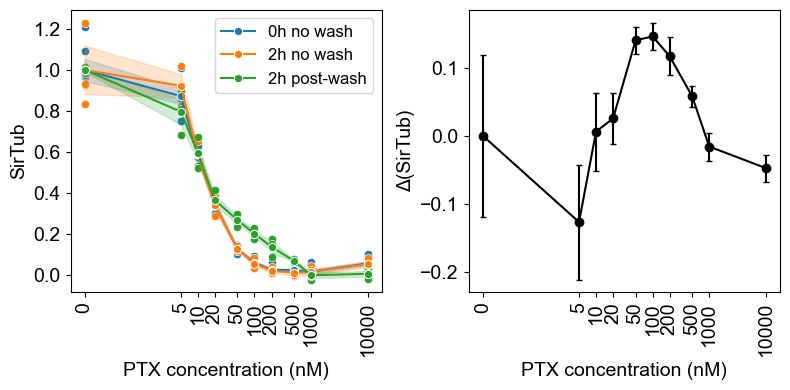

In [4]:
colors = plt.cm.tab10.colors
color1 = colors[0]
color2 = colors[1]
color3 = colors[2]

_, ax = plt.subplots(1, 2, figsize=(8, 4))
sns.scatterplot(
    data=well_data_1,
    x="c",
    y="Normalized fluorescence",
    ax=ax[0],
    color=color1,
)
sns.scatterplot(
    data=well_data_2[well_data_2.row.isin(list("EFG"))],
    x="c",
    y="Normalized fluorescence",
    ax=ax[0],
    color=color2,
)
sns.scatterplot(
    data=well_data_2[well_data_2.row.isin(list("BCD"))],
    x="c",
    y="Normalized fluorescence",
    ax=ax[0],
    color=color3,
)
sns.lineplot(
    data=well_data_1,
    x="c",
    y="Normalized fluorescence",
    errorbar="se",
    marker="o",
    ax=ax[0],
    label="0h no wash",
    color=color1,
)
sns.lineplot(
    data=well_data_2[well_data_2.row.isin(list("EFG"))],
    x="c",
    y="Normalized fluorescence",
    errorbar="se",
    marker="o",
    ax=ax[0],
    label="2h no wash",
    color=color2,
)
sns.lineplot(
    data=well_data_2[well_data_2.row.isin(list("BCD"))],
    x="c",
    y="Normalized fluorescence",
    errorbar="se",
    marker="o",
    ax=ax[0],
    label="2h post-wash",
    color=color3,
)

for bx in ax:
    bx.set_xscale("log")

c = well_data_1.c.unique()
fl_wash_grouped = well_data_2[well_data_2.row.isin(list("BCD"))][["c", "Normalized fluorescence"]].groupby("c") 
fl_no_wash_grouped = well_data_2[well_data_2.row.isin(list("EFG"))][["c", "Normalized fluorescence"]].groupby("c") 
fl_wash = fl_wash_grouped.mean().values.flatten()
fl_no_wash = fl_no_wash_grouped.mean().values.flatten()
fl_wash_var = fl_wash_grouped.var().values 
fl_no_wash_var = fl_no_wash_grouped.var().values
se = np.sqrt(fl_wash_var / 3 + fl_no_wash_var / 3).flatten()

ax[1].errorbar(c, (fl_wash - fl_no_wash), yerr=se, marker="o", capsize=2, color="black")
ax[0].set_ylabel("SirTub")
ax[1].set_ylabel("Δ(SirTub)")
ax[0].legend(fontsize=12)
for bx in ax:
    bx.set_xlabel("PTX concentration (nM)")
    bx.set_xticks(c)
    bx.set_xticklabels([0, 5, 10, 20, 50, 100, 200, 500, 1000, 10000], rotation=90)
save_fig("SirTub_site_occupancy", fmt="png", dpi=300)

# Images

In [5]:
dir = Path(
    "../data/BYL276/BYL276-before-wash/2025-04-06/20735/TimePoint_1/"
)
well_of_interest = [l + str(n).zfill(2) for l, n in ["B2", "B9", "F9"]]
im_pool = {k: [] for k in well_of_interest}
for well in tqdm(well_of_interest):
    for ch in range(1, 3):
        im_files = list(dir.glob(f"BYL276-before-wash_{well}_s1_w{ch}*.tif"))
        im_file = [f for f in im_files if "thumb" not in str(f)][0]
        im = np.array(Image.open(im_file))
        im_pool[well].append(im[500:1000, 500:1000])

dir = Path(
    "../data/BYL276/BYL276-1h/2025-04-06/20736/TimePoint_1/"
)
well_of_interest = [l + str(n).zfill(2) for l, n in ["B2", "B9", "F9"]]
im_pool_2 = {k + "_2h": [] for k in well_of_interest}
for well in tqdm(well_of_interest):
    for ch in range(1, 3):
        im_files = list(dir.glob(f"BYL276-1h_{well}_s1_w{ch}*.tif"))
        im_file = [f for f in im_files if "thumb" not in str(f)][0]
        im = np.array(Image.open(im_file))
        im_pool_2[well + "_2h"].append(im[500:1000, 500:1000])

im_pool.update(im_pool_2)
im_pool.keys()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 33.92it/s]


dict_keys(['B02', 'B09', 'F09', 'B02_2h', 'B09_2h', 'F09_2h'])

Saving figure SirTub_site_occpancy


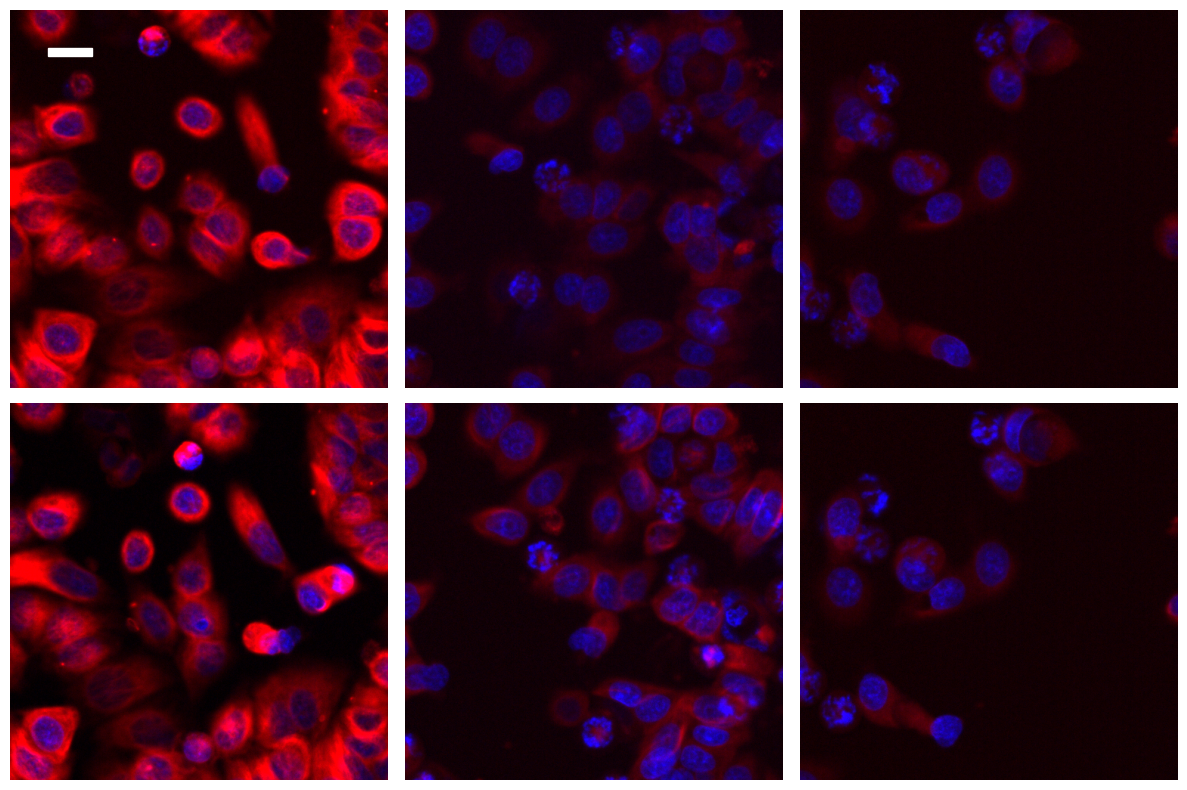

In [6]:
fig, ax = multimshow(
    im_pool,
    adjust_thresh=[(20, 99.8), (2, 98)],
    chans=[0, 1],
    ch_to_lut={0: 2, 1: 0},
    nrows=2,
    ncols=3,
    show_multi_chan=False,
    adjust_to_first_im=[True, True],
    # xlabels=[
    #     "DMSO (wash)",
    #     "500nM PTX (wash)",
    #     "500nM PTX (no wash)",
    # ],
    # ylabels=["0h", "2h"],
    order="C",
    fontsize=22,
    merge=True,
    brightness_exclude=[],
)

from matplotlib.patches import Rectangle
scalebar = Rectangle((50, 50), 20 // 0.3425, 10, color="white")
ax[0,0].add_patch(scalebar)

save_fig("SirTub_site_occpancy", fmt="png", dpi=300)